In [8]:
class SchoolApplication:
    def __init__(self, date, name, school, type_, rating, tuition_fee, acceptance_rate):
        self.date = date
        self.name = name
        self.school = school
        self.type = type_
        self.rating = rating
        self.tuition_fee = tuition_fee
        self.acceptance_rate = acceptance_rate
        self.unique_id = id(self)

    def __str__(self):
        return f"{self.unique_id},{self.date},{self.name},{self.school},{self.type},{self.rating},{self.tuition_fee},{self.acceptance_rate}"

class StemSchoolApplication(SchoolApplication):
    def __init__(self, date, name, school, rating, tuition_fee, acceptance_rate):
        super().__init__(date, name, school, "Stem", rating, tuition_fee, acceptance_rate)

class NonStemSchoolApplication(SchoolApplication):
    def __init__(self, date, name, school, rating, tuition_fee, acceptance_rate):
        super().__init__(date, name, school, "non-Stem", rating, tuition_fee, acceptance_rate)

class Caltech(StemSchoolApplication):
    def __init__(self, date, name, rating, tuition_fee, acceptance_rate):
        super().__init__(date, name, "Caltech", rating, tuition_fee, acceptance_rate)

class Harvard(NonStemSchoolApplication):
    def __init__(self, date, name, rating, tuition_fee, acceptance_rate):
        super().__init__(date, name, "Harvard", rating, tuition_fee, acceptance_rate)

class Yale(NonStemSchoolApplication):
    def __init__(self, date, name, rating, tuition_fee, acceptance_rate):
        super().__init__(date, name, "Yale", rating, tuition_fee, acceptance_rate)

#harvard_app = Harvard("2024-11-15", "LAW401", 2, 641, 86.06)
#print(str(harvard_app))



# Upload the DAT file to Colab's session storage
import pickle

dat_file_path = '/content/SchoolApplicationpkl638250307.dat'

# Load the pickle file
with open(dat_file_path, 'rb') as file:
    objects = pickle.load(file)

print(f"Total objects loaded: {len(objects)}")

print(objects[0])

csv_file_path = '/content/school_applications.csv'

with open(csv_file_path, 'w') as f:

    f.write("uniqueId,date,name,school,type,rating,tuition_fee,acceptance_rate\n")

    for obj in objects:
        f.write(str(obj) + '\n')

print(f"CSV file created at {csv_file_path}")



import pandas as pd

df = pd.read_csv('/content/school_applications.csv')

print(df.head())

print("\nMissing values per column:")
print(df.isnull().sum())

# Handle missing values
# Categorical columns: 'date', 'name', 'school', 'type'
categorical_cols = ['date', 'name', 'school', 'type']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Numerical columns: 'rating', 'tuition_fee', 'acceptance_rate'
numerical_cols = ['rating', 'tuition_fee', 'acceptance_rate']
for col in numerical_cols:
    df[col].fillna(df[col].mean(), inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())

import matplotlib.pyplot as plt

Total objects loaded: 12000
140525962630800,2024-03-20,CS401,Caltech,Stem,5,15240,95.59
CSV file created at /content/school_applications.csv
          uniqueId        date   name   school  type  rating  tuition_fee  \
0  140525962630800  2024-03-20  CS401  Caltech  Stem     5.0      15240.0   
1  140525185435472  2024-12-06  CS501  Caltech  Stem     5.0      20488.0   
2  140525136263248  2024-04-16  CS501  Caltech  Stem     5.0      21475.0   
3  140525182460432  2024-09-13  CS501  Caltech  Stem     5.0      20057.0   
4  140525183011536  2024-09-29  CS501  Caltech  Stem     5.0          NaN   

   acceptance_rate  
0            95.59  
1            86.45  
2            65.41  
3            74.51  
4              NaN  

Missing values per column:
uniqueId             0
date               478
name                 0
school               0
type                 0
rating             507
tuition_fee        944
acceptance_rate    944
dtype: int64

Missing values after cleaning:
uniqueId     

/tmp/ipykernel_2171/2084807045.py:79: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_2171/2084807045.py:84: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

**Introduction to dataset:** The dataset "school_applications" consisted of 12,000 school applications. It included attributes such as: date, school, type (stem or non-stem), rating, tuition_fee, and acceptance_rate. I utilized object-oriented programing in python to build and analyze seven visualizations that helped us identify patterns in application trends and how factors such as: college, major, tuition, *and more* attracts applicants in the process of applying to the three universities represented in our dataset: Caltech, Yale, and Harvard. The visualizations consist of a bar graph, a box plot, line plot, scatter plot, histogram, pie chart, and lastly a heat map; all showcasting different aspects of what drives students to apply to their desired university.

**How I dealt with missing values in the data:** Missing values were handeled by filling categorical columns (date,name,school,type) with their most frequent value (mode). Numerical columns (rating, tuition_fee, acceptace_rate) were filled with their mean values. This ensured a complete dataset without introducing significant bias.

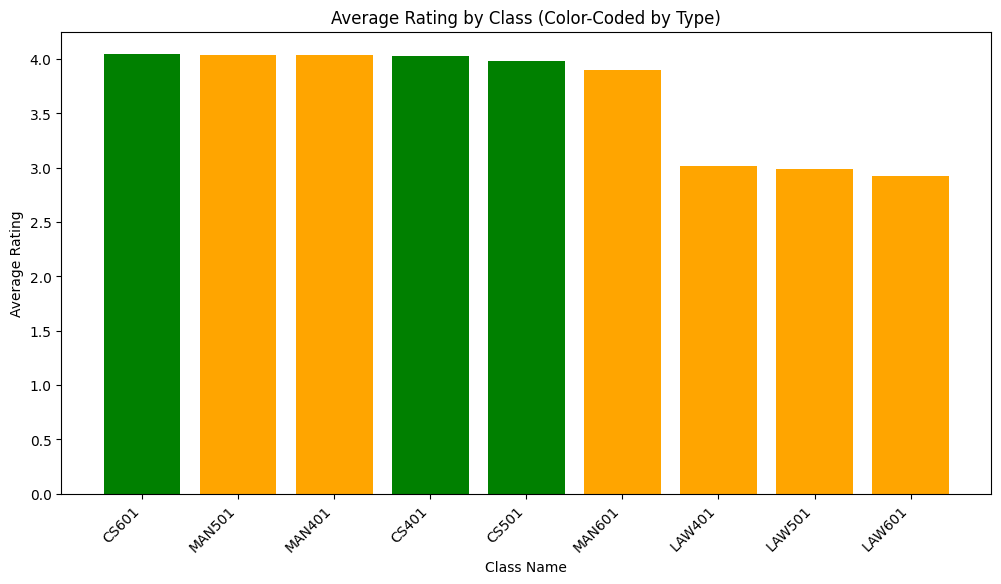

In [ ]:
#bar chart
average_rating_by_class = df.groupby('name')['rating'].mean().sort_values(ascending=False)
class_types = df.groupby('name')['type'].first()[average_rating_by_class.index]

colors = []
for class_type in class_types:
    if class_type == 'Stem':
        colors.append('green')
    elif class_type == 'non-Stem':
        colors.append('orange')
    else:
        colors.append(None)


plt.figure(figsize=(12, 6))
class_names = average_rating_by_class.index
height = average_rating_by_class.values

plt.bar(class_names, height, color=colors)
plt.xlabel('Class Name')
plt.ylabel('Average Rating')
plt.title('Average Rating by Class (Color-Coded by Type)')
plt.xticks(rotation=45, ha='right')
plt.show()

**Bar Chart**: This bar chart provides insights into the average rating of each class/major provided in the dataset. The green indicates that the class is a STEM class, whereas the orange indicates that the course is a Non-STEM course to easily distinguish between the two. For computer science, you can see that CS601 has the highest ratings. This information would especially be helpful for students who are planning on exploring computer science or a related STEM degree. This chart can assist prospective students in identifying which school offers high quality courses for their intended major.

/tmp/ipykernel_1048/752123977.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=schools)


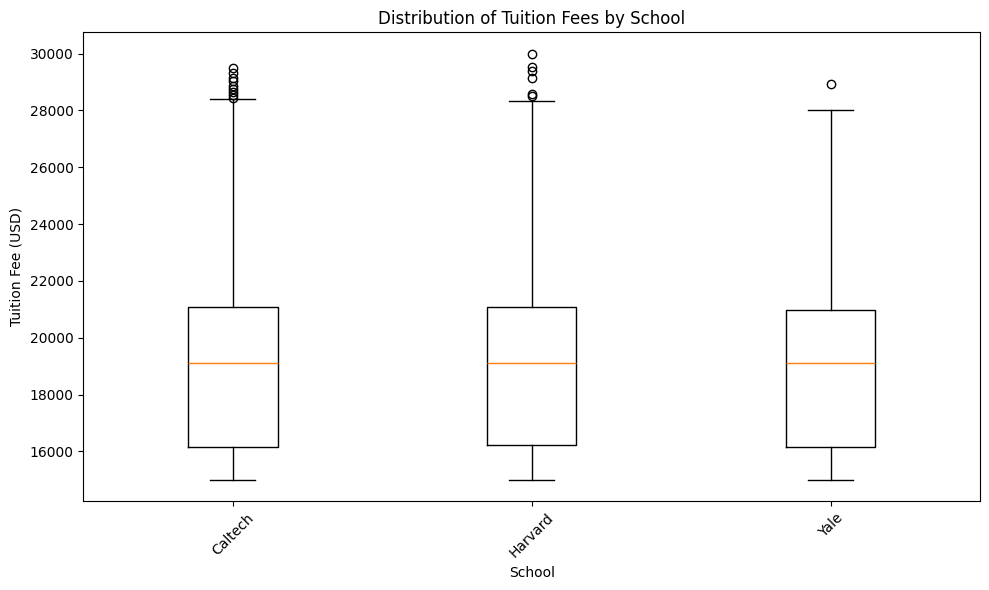

In [ ]:
#boxplot
schools = df['school'].unique()
data = [df[df['school'] == school]['tuition_fee'] for school in schools]

plt.figure(figsize=(10,6))
plt.boxplot(data, labels=schools)
plt.xlabel('School')
plt.ylabel('Tuition Fee (USD)')
plt.title('Distribution of Tuition Fees by School')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Box Plot:** The Box Plot above gives insights into the distribution of tuition fees for each school. By comparing the positions and sizes of these elements across the schools, you can quickly identify which university has a higher median tuition, greater variability in fees, and the presence of any significant outliers in their tuition data. Although the schools have a very similar average tuition amounts, Yale stands at the lowest out of the three [at about 19,034.] This could be due to various factors with this dataset such as: the number of applicants that apply to the school, or size and scale of a school. Harvard and Caltech also have many outliers when compared to Yale which has only one outlier. This can be due to many factors such as variation in pay due to finacial aid availability, scholarships, or uniformity of tuition across the student body. If a prospective student is choosing between the two schools, and tuition price is a big decision factor, Yale might be the best choice for them.

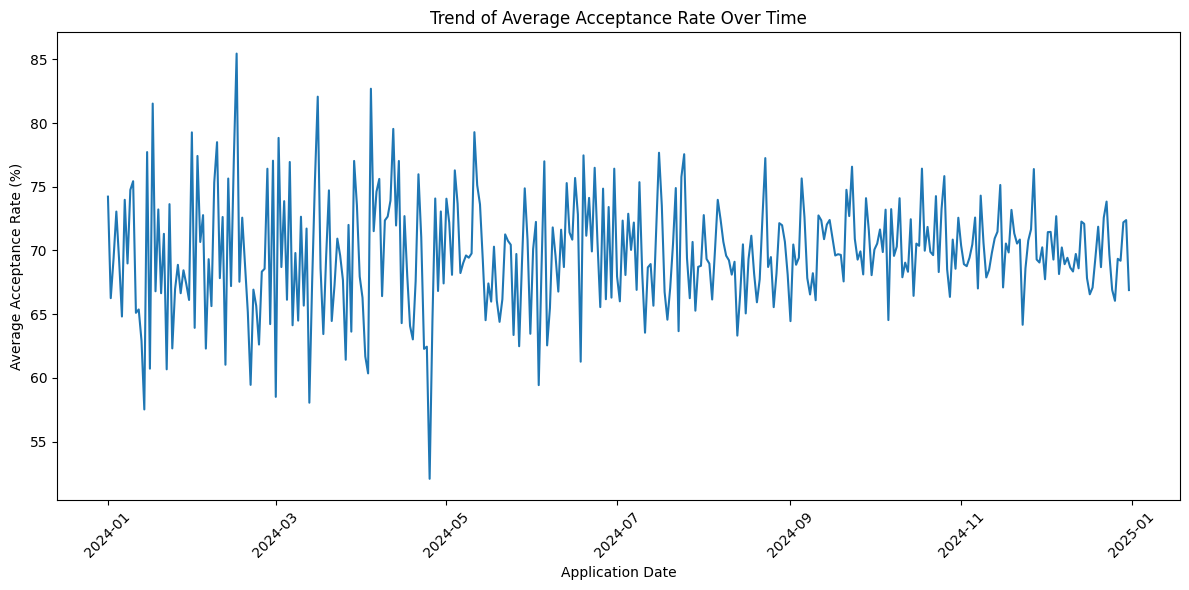

In [ ]:
df['date'] = pd.to_datetime(df['date'])

# Group by date and calculate average acceptance rate
date_avg_acceptance = df.groupby('date')['acceptance_rate'].mean().sort_index()

# Line plot
plt.figure(figsize=(12,6))
plt.plot(date_avg_acceptance.index, date_avg_acceptance.values)
plt.xlabel('Application Date')
plt.ylabel('Average Acceptance Rate (%)')
plt.title('Trend of Average Acceptance Rate Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Line Plot**: The line plot above depicts the trend of the average acceptance rate over time. This graph would be useful for showcasing how acceptance rates change over time, and can also help a prospective student estimate their chances of getting into a university. In this chart, there is a steep drop around the end of April 2024. This can indicate several factors such as a high amount of applicants versus a few that got admitted. On the other hand you can see that the highest number of acceptances across the schools (around 85%) was toward the end of February. This is most likely due to the schools finalizing their admissions for the spring semester by that date. By analyzing this graph, students can better gauge when acceptance rates peak or drop, helping them plan and target their application submissions more effectively.

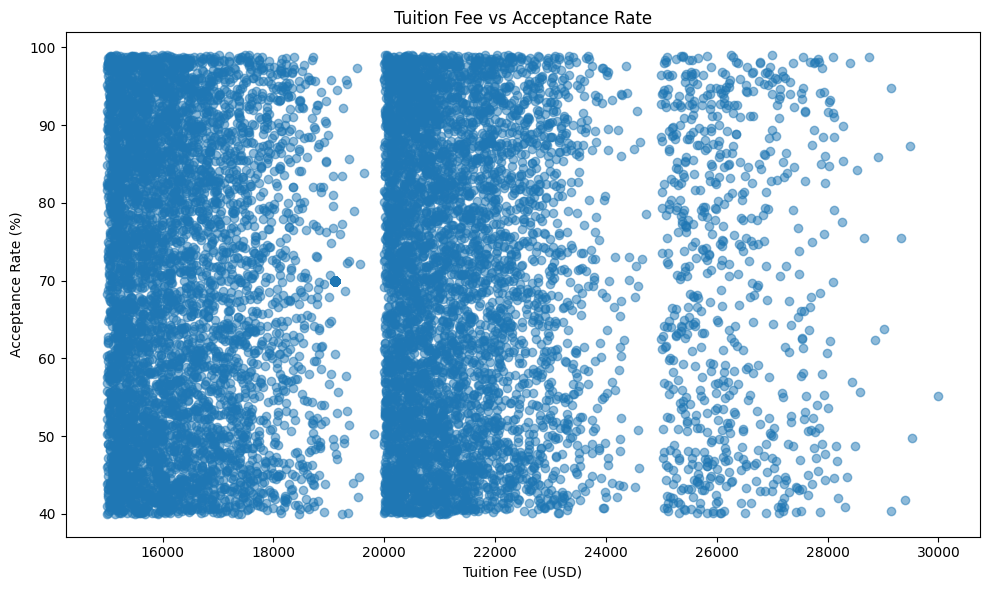

In [ ]:
# Scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df['tuition_fee'], df['acceptance_rate'], alpha=0.5)
plt.xlabel('Tuition Fee (USD)')
plt.ylabel('Acceptance Rate (%)')
plt.title('Tuition Fee vs Acceptance Rate')
plt.tight_layout()
plt.show()

**Scatter Plot:** The Scatter Plot above showcases the relationship between acceptance rate and tuition fee. We can see that when the tuition fee is lower there is a higher chance of getting accepted, thus drawing in more applicants, as shown in the left, more denser area of the graph. In contrast, higher tuition on the right side of the graph appears less populated, meaning that the schools recieve fewer applicants. This graph suggests that affordability in tuition plays a significant role in school selection and application trends.

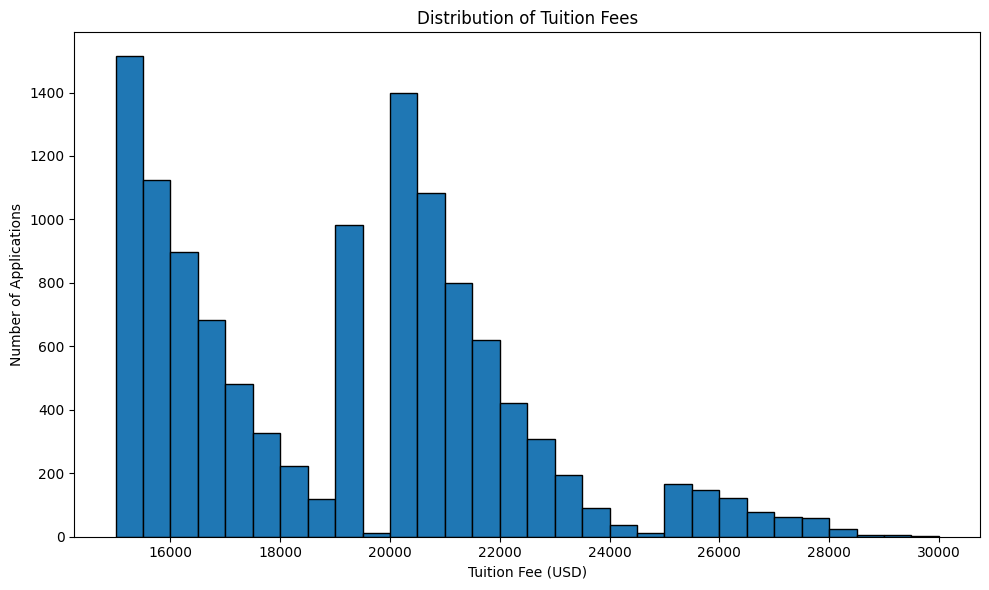

In [ ]:
# Histogram
plt.figure(figsize=(10,6))
plt.hist(df['tuition_fee'], bins=30, edgecolor='black')
plt.xlabel('Tuition Fee (USD)')
plt.ylabel('Number of Applications')
plt.title('Distribution of Tuition Fees')
plt.tight_layout()
plt.show()

# Count applications per school
school_counts = df['school'].value_counts()

**Histogram:** The histogram above showcases the distribution of tuition fees in comparison to the number of applicants. Similar to the visualization above, in this graph you can see that generally higher tuition results in less applicants. On the other hand, the lower end of the tuition rates in this dataset results in a higher volume of applicants applying. This graph supports the trend that lower tuition is more affordable, attracting more applicants while higher tuition can have the opposite effects due to cost comparisons.

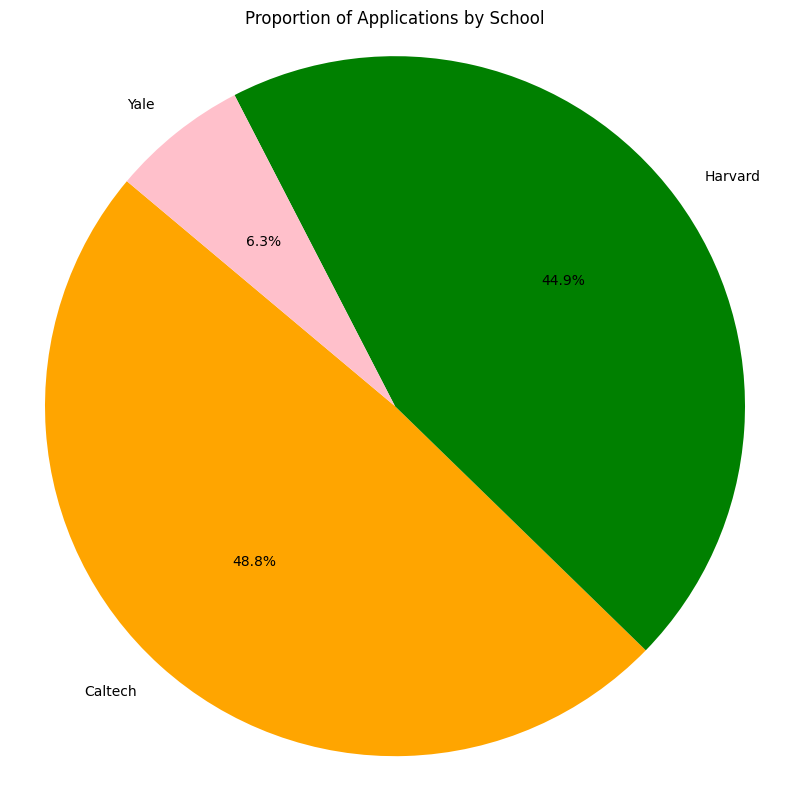

In [ ]:
# Count applications per school
school_counts = df['school'].value_counts()

# Pie chart
plt.figure(figsize=(8,8))
colors=["orange","green","pink"]
plt.pie(school_counts.values, labels=school_counts.index,colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Applications by School')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Pie Chart**: In the pie chart above, you can assess the proportion of applicants from each school. Harvard has the highest percentage of applicants out of the three followed by Caltech. This could be due to the school being widely known or appealing to a larger group of students and may offer diverse programs. Yale on the other hand has the fewest amount of applicants in this dataset possibly due to a fewer amount of students that may apply. This chart can also depict how much appeal one school has in comparison to the other and which school might be more selective of applicants.

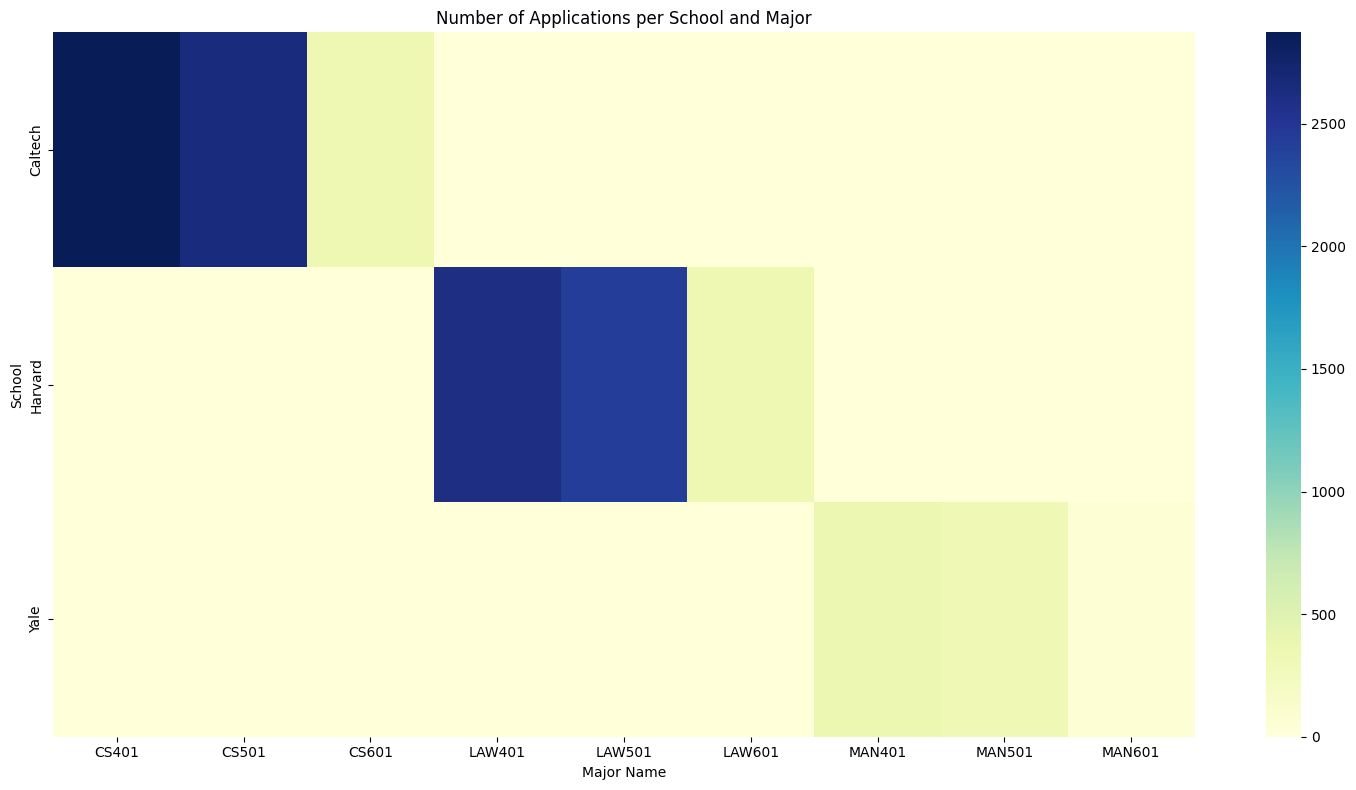

In [ ]:
!pip install seaborn

import seaborn as sns

pivot_table = df.pivot_table(index='school', columns='name', aggfunc='size', fill_value=0)

plt.figure(figsize=(15,8))
sns.heatmap(pivot_table, cmap='YlGnBu')
plt.title('Number of Applications per School and Major')
plt.xlabel('Major Name')
plt.ylabel('School')
plt.tight_layout()
plt.show()

**Heat Map:**
The heat map above showcases the number of applications per school and major. You can see that Caltech has a higher number of applicants (about 2500) interested in a computer science course. This indicates that students who want to persue a degree in STEM have a higher chance of applying to Caltech rather than Harvard or Yale. Harvard has a high volume of applicants interested in law, This indicates that a prospective law student will most likely be interested in persuing their major in Harvard rather than Caltech or Yale. Overall, this heatmap highlights how student interest in specific majors varies significantly by school.

**Conclusion:**
In conclusion, this dataset enabled me to build and analyze trends across three well-known and prestigous universities. I was able to compare tuition rates, ratings for different courses, acceptance rates, changes to acceptance rates over time, and much more. These data points collectively offer a clearer picture of what may attract applicants as they navigate their educational journey.

**Recommendations:** Some recommendations to improve the dataset involve:


1.   Having more variety in the types of colleges: This dataset only showcased three universities. Although all three shared the characteristic of being prestigious, including a broader range of institutions would provide more options and generalized insights.
2.   Currently the dataset consists of three majors and two types of majors (STEM or Non-STEM). Including a wider range of majors would capture a more diverse academic interest and allow for better analysis across different fields of study.
3. Cleaning missing or inconsistent values in the original dataset will allow for more reliable and meaningful insights.




In [ ]:
# Save the cleaned dataframe to a new CSV file
df.to_csv('/content/school_applications_cleaned.csv', index=False)

**To save the cleaned dataframe as a separate CSV file. (Optional)**